# Simple Scheduling Algorithm using QAOA



N tasks    \
M workers  \
M <= N     

Assign tasks to workers    \
Each task assigned only to one worker

input  - Weight matrix, W \
output - optimized scheuling of tasks to workers resulting a least cost \
                      \
W(i, j) indicate the cost of jth task assigned to ith worker



### QAOA procedure for Simple Scheduling

1. Weight matrix to QUBO Cost

2. QUBO Cost to Hamiltonian

3. QAOA Circuit
    * QAOA Ansatz
    * Transpile to Aer Simulator circuit

4. Optimization
    * Estimator for evaluating Energy or Cost
    * Classical parameter optimization through minimize function

5. Results
    * Generate Sampler output of the circuit assigned with best parameters
    * Optimal Scheduling
    * Visualization



In [1]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\kcrav\miniconda3\envs\myenv\python.exe
Python version: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


In [2]:
#!jupyter kernelspec list

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from scipy.optimize import minimize

## Weight matrix to Classical QUBO Cost




In [4]:
N = 5
M = 3
p_reps = 2

init_param_values = []

if p_reps == 4:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 6, np.pi/4.8, np.pi / 5]
elif p_reps == 3:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 5]
elif p_reps == 2:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 5, np.pi/4.5]
elif p_reps == 1:
    init_param_values = [np.pi / 3, np.pi / 6]

assert N > 0 and M > 0, "N and M must be positive integers."
#assert N >= M, "N must be greater than or equal to M for a valid scheduling problem."

def generate_weight_matrix(M, N):
    w = np.random.randint(1, 1000, size=(M, N))
    return w

w = generate_weight_matrix(M, N)
print('w:', w)

w_col = w.reshape(-1, 1)


w: [[ 17 886 227 854 993]
 [ 98 401 635 608 400]
 [850 595 423  96 610]]


In [ ]:
'''
L = 10*int(np.ceil(sum(w_col.flatten())/N))  # sum of all MxN weights divided by N, ceiled to the nearest integer. Since Sigma(i=1 to M) Sigma(j=1 to N) x_ij = N, so divide by N
Q = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones
for i in range(M * N):
    for j in range(int(np.floor(i/M)*M),i):
        Q[i, j] = 2*L
C = 0.00001*w_col - L*np.ones((M * N, 1))

#print(np.diag(Q))
#print(np.diag(np.diag(Q)))
#Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero

print('Q:', Q)
print('C:', C)
'''

In [ ]:
L = 1*int(np.ceil(sum(w_col.flatten())/N))  # sum of all MxN weights divided by N, ceiled to the nearest integer. Since Sigma(i=1 to M) Sigma(j=1 to N) x_ij = N, so divide by N
Q = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones
for j in range(N):
    for i in range(M):
        for l in range(i):
            Q[i * N + j, l * N + j] = 2/(N)
            #Q[i * N + j, l * N + j] = 1/(N)
            #Q[l * N + j, i * N + j] = 1/(N)
            #Q[i * N + j, l * N + j] = 2*L
            #Q[i * N + j, l * N + j] = L
            #Q[l * N + j, i * N + j] = L
C = w_col/(np.sum(w_col)) - 1/(N)*np.ones((M * N, 1))
#C = w_col*(.5/(2*L)) - .5*np.ones((M * N, 1))
#C = .1*w_col - L*np.ones((M * N, 1))

#print(np.diag(Q))
#print(np.diag(np.diag(Q)))
#Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero


print('Q:', Q)
print('C:', C)

In [7]:
def qubo_cost_function(x, Q, C):
    return 0.5 * x.T @ Q @ x + C.T @ x


# brute-force search for CLASSICAL optimal solution
min_cost = 100000
min_bitstring = None
max_cost = -100000
max_bitstring = None
for i in range(2**(M*N)):
    x = np.array(list(np.binary_repr(i, width=M*N)), dtype=int)
    cost = qubo_cost_function(x, Q, C)
    #print(f"x: {x}, cost: {cost}")
    #print(f"x: {x}, x.T @ Q @ x: {x.T @ Q @ x}, C.T @ x: {C.T @ x}")
    if cost < min_cost:
        min_cost = cost
        min_bitstring = x
    if cost > max_cost:
        max_cost = cost
        max_bitstring = x

#print(f"Maximum cost: {max_cost}, achieved by bitstring: {max_bitstring}, \n reshaped bitstring: \n {max_bitstring.reshape(M, N)}")
print(f"Minimum cost: {min_cost}, achieved by bitstring: {min_bitstring}, \n reshaped bitstring: \n {min_bitstring.reshape(M, N)}")
print('w:', w)
print('w_col: \n', w_col)

Minimum cost: [-0.85168335], achieved by bitstring: [1 0 1 0 0 0 1 0 0 1 0 0 0 1 0], 
 reshaped bitstring: 
 [[1 0 1 0 0]
 [0 1 0 0 1]
 [0 0 0 1 0]]
w: [[ 17 886 227 854 993]
 [ 98 401 635 608 400]
 [850 595 423  96 610]]
w_col: 
 [[ 17]
 [886]
 [227]
 [854]
 [993]
 [ 98]
 [401]
 [635]
 [608]
 [400]
 [850]
 [595]
 [423]
 [ 96]
 [610]]


## Classical QUBO to Hamiltonian




In [8]:
C[1][0], Q[5,:]

(np.float64(-0.08483036526712597),
 array([0.4, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. ]))

In [9]:
def classical_qubo_to_hamiltonian(Q, C):
    n = len(C)
    pauli_list = []
    
    for i in range(n):
        if C[i] != 0 or np.sum(Q[i,:]) != 0:
            pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/4 + np.sum(Q[:,i])/4 + C[i][0]/2)))
            #pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/2 + C[i][0]/2)))
            pass
    
    for i in range(n):
        for j in range(i):
            if Q[i, j] != 0:
                pauli_list.append(('ZZ', [i, j], np.float64(Q[i, j]/4)))
                pauli_list.append(('ZZ', [j, i], np.float64(Q[j, i]/4)))
                pass
    
    return pauli_list

In [ ]:
pauli_list = classical_qubo_to_hamiltonian(Q, C)
no_of_qubits = M * N
Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=no_of_qubits)
Cost_hamiltonian


## QAOA Circuit

### QAOA Ansatz


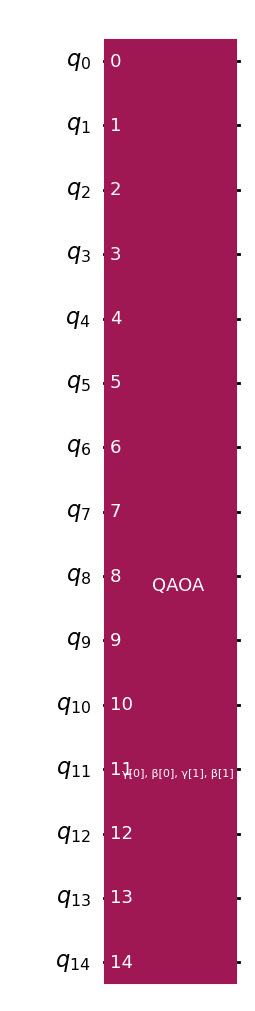

In [11]:
circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_reps)
#circuit.measure_all()

circuit.draw("mpl")

In [12]:
#circuit.decompose().draw("mpl")


### Transpile to Aer Simulator circuit


In [13]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

In [14]:
binding_dict = {param: value for param, value in zip(circuit.parameters, init_param_values)}
bound_circuit = circuit.assign_parameters(binding_dict)
bound_circuit.parameters

ParameterView([])

In [15]:
simulator = AerSimulator(method="statevector")
Aer_transpiled_ckt = transpile(circuit, simulator)

Aer_transpiled_ckt.save_statevector()

#Aer_transpiled_ckt.draw("mpl")

### State vector simulation (checking for initial parameters)

In [16]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(binding_dict)

results = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results.get_counts()
#plot_histogram(counts, title="State Vector without measurement")

In [17]:
state_vector = results.get_statevector()

#plot_state_city(state_vector, title="State Vector City Plot")

## Optimization

### Estimator for evaluating Energy or Cost



In [18]:
obj_fn_costs_iter = []
parameter_values_iter = []

In [19]:
def Average_Energy(parameter_values, transpiled_circuit, Cost_hamiltonian, estimator):
    # Bind the parameters to the circuit
    binding_dict = {param: value for param, value in zip(transpiled_circuit.parameters, parameter_values)}
    #bound_circuit = transpiled_circuit.assign_parameters(binding_dict)

    #isa_hamiltonian = Cost_hamiltonian.apply_layout(bound_circuit.layout)
    isa_hamiltonian = Cost_hamiltonian.apply_layout(transpiled_circuit.layout)

    #display(bound_circuit.draw("mpl"))

    # Simulate the circuit to get the state vector
    #simulator = AerSimulator(method='statevector')
    #transpiled_ckt = transpile(bound_circuit, simulator)

    #print(Cost_hamiltonian)
    #print(isa_hamiltonian)
    
    #print(transpiled_circuit.parameters)
    #print(len(transpiled_circuit.parameters))

    #print(bound_circuit.parameters)
    #print(len(bound_circuit.parameters))

    pub = (transpiled_circuit, isa_hamiltonian, parameter_values)
    #pub = (bound_circuit, isa_hamiltonian, parameter_values)
    results = estimator.run([pub]).result()

    #print(results[0].data.evs)

    #state_vector = results[0].get_statevector()


    # Compute the expectation value of the cost Hamiltonian
    #stateVect = np.array(state_vector)
    #cost_Mx = np.array(Cost_hamiltonian.to_matrix())
    #energy = np.real(stateVect.conj().T @ cost_Mx @ stateVect)

    #print("Expected Values:", results[0].data.evs)
    #print("Energy:", energy)

    obj_fn_costs_iter.append(results[0].data.evs)
    parameter_values_iter.append(list(parameter_values))


    return results[0].data.evs # energy

### Parameter optimization through minimize function

Hybrid Quantum-Classical workflow
- Parameter optimization - Classical processing
- Energy calculation - QPU/Simulator


Optimal parameters: [2.54018614 0.16304638 2.20539077 0.25494811]
Minimum energy: -0.8356874724536512


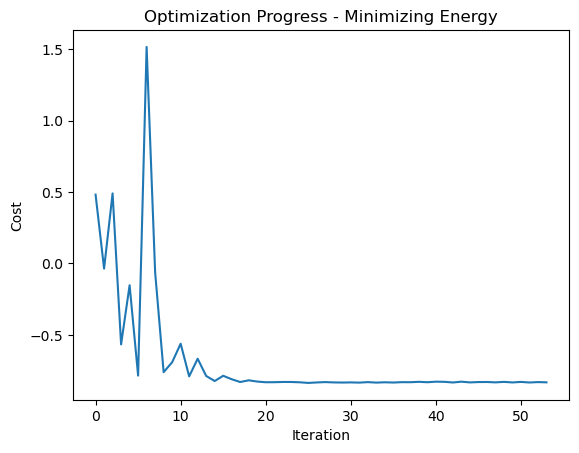

In [20]:
obj_fn_costs_iter = []
parameter_values_iter = []

simulator = AerSimulator(method="statevector")
Aer_transpiled_ckt = transpile(circuit, simulator)

estimator = Estimator(mode=simulator)
estimator.options.default_shots = 1024*16

param_values_init = [0.77254496, 1.24810316] # [553/L, 1.2481] # [10/L, 10/L]
param_values_init = [2.30713335, 0.9512575 ] # [.002, .01] # [553/L, 1.2481] # [10/L, 10/L]
param_values_init = init_param_values

result = minimize(
        Average_Energy,
        param_values_init,
        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-6,
        #options={'rhobeg': .0001},
)

optimal_parameters = result.x
optimal_energy = result.fun

print("Optimal parameters:", result.x)
print("Minimum energy:", result.fun)

plt.plot(obj_fn_costs_iter)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Optimization Progress - Minimizing Energy")
plt.show()

In [21]:
parameter_values = [-0.913, -1.248]
parameter_values = [-0.8, -1.2481]
parameter_values = [10000/L, 1.2481]

estimator.options.default_shots = 1024*32
isa_hamiltonian = Cost_hamiltonian.apply_layout(Aer_transpiled_ckt.layout)

In [ ]:
'''parameter_values = [553/L, 1.2481] # [100000/L, 1.2481]

pub = (Aer_transpiled_ckt, Cost_hamiltonian, parameter_values)
results = estimator.run([pub]).result()

results[0].data.evs '''

In [ ]:
'''
from qiskit_algorithms.optimizers import ADAM
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import QAOA
from qiskit_aer import Aer

backend = Aer.get_backend("statevector_simulator")
qaoa = QAOA(optimizer = ADAM(maxiter=200, lr=0.01), sampler=backend, initial_point=init_param_values, reps = 1)
eigen_optimizer = MinimumEigenOptimizer(min_eigen_solver=qaoa)

eigen_optimizer.solve(Cost_hamiltonian)
'''

In [ ]:
list(zip(parameter_values_iter, obj_fn_costs_iter))

history = []
history = ([[float(round(parameter_values_iter[i][0],8)), float(round(parameter_values_iter[i][1],8)), round(float(obj_fn_costs_iter[i]),3)] for i in range(len(parameter_values_iter))])

print('  gama,  beta,  cost')
history

In [25]:
print("Optimal parameters, minimum energy:")
[float(round(optimal_parameters[0],3)), float(round(optimal_parameters[1],3)), round(float(optimal_energy),3)] 

Optimal parameters, minimum energy:


[2.54, 0.163, -0.836]

## Results


### Generate Sampler output of the circuit assigned with best parameters


In [ ]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)
bound_Aer_transpiled_ckt.measure_all()

#display(bound_Aer_transpiled_ckt.draw("mpl"))

sampler = Sampler(mode=simulator)
sampler.options.default_shots = 1024*16
result = sampler.run([bound_Aer_transpiled_ckt]).result()
#print("result:", result)

print(result[0].data.meas.get_counts())

#print(result[0].data.keys(), result[0].data.values(), result[0].data.ndim, result[0].data.shape, result[0].data.size)

'''
bit_strings, frequencies = zip(*sorted(zip(result[0].data.meas.get_counts().keys(), list(result[0].data.meas.get_counts().values()))))
Probabilites = [frequencies[i]/sum(frequencies) for i in range(len(frequencies))]
plt.bar(bit_strings, Probabilites)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Probability')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()

plot_histogram(result[0].data.meas.get_counts(), title="Measurement results with optimal parameters with #layers = " + str(p_reps))

'''

In [ ]:
'''
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)

results_StateVector = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results_StateVector.get_counts()
plot_histogram(counts, title="State Vector without measurement")
'''

### Optimal Scheduling


In [ ]:
frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))
'''
plt.bar(bit_strings, frequencies)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Frequency')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()
'''



### Visualization

In [29]:
#f=L/10
#plt.plot(np.sin(np.arange(0, 1, 0.001)*f*2*np.pi))



In [30]:
print("Optimal parameters, minimum energy:")
[float(round(optimal_parameters[0],3)), float(round(optimal_parameters[1],3)), round(float(optimal_energy),3)] 

Optimal parameters, minimum energy:


[2.54, 0.163, -0.836]

In [31]:
def solution_at_sampler_matched_idx(bit_strings, w, min_bitstring):

    bit_strings_output = []

    for ir in range(len(bit_strings)):
        bit_strings_output.append([int(bit_strings[ir][i]) for i in range(len(bit_strings[0]))])
        bit_strings_output[ir].reverse()
        matched_idx = ir
        for i in range(len(bit_strings_output[ir])):
            if bit_strings_output[ir][i] != min_bitstring[i]:
                matched_idx = None
                break
        if matched_idx is not None:
            break

    #bit_strings_output = [int(bit_strings[ir][i]) for i in range(len(bit_strings[0]))]
    #bit_strings_output = np.flip(bit_strings_output)

    print('w:\n',w)
    print('c:\n',min_bitstring.reshape(M, N))
    print('q:\n',np.array(bit_strings_output[0]).reshape(M, N))
    print(f"\n (Solution at sampler freq matched idx) idx |  #samples    | 2**(M*N) \n", '-'*70 )
    print(' '*35, f"   {matched_idx}     {len(bit_strings)}       {2**((M*N))}")

solution_at_sampler_matched_idx(bit_strings, w, min_bitstring)


w:
 [[ 17 886 227 854 993]
 [ 98 401 635 608 400]
 [850 595 423  96 610]]
c:
 [[1 0 1 0 0]
 [0 1 0 0 1]
 [0 0 0 1 0]]
q:
 [[1 0 0 0 0]
 [0 1 1 0 1]
 [0 0 0 1 0]]

 (Solution at sampler freq matched idx) idx |  #samples    | 2**(M*N) 
 ----------------------------------------------------------------------
                                       13     6592       32768


# (End-to-end in one block. Utility functions above)

In [32]:
dict = {}
N=5
M=4
#for n_samples in range(50):
for n_train in range(1):

    #w = np.array([[37, 41, 31, 26, 79], [39, 50,  1, 46, 81]])
    w = generate_weight_matrix(M, N)
    w_col = w.reshape(-1, 1)

    Q = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones
    for j in range(N):
        for i in range(M):
            for l in range(i):
                Q[i * N + j, l * N + j] = 2/(N)
                #Q[i * N + j, l * N + j] = 1/(N)
                #Q[l * N + j, i * N + j] = 1/(N)
    C = w_col/(np.sum(w_col)) - 1/(N)*np.ones((M * N, 1))

    pauli_list = classical_qubo_to_hamiltonian(Q, C)
    Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=M * N)

    circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_reps)

    obj_fn_costs_iter = []
    parameter_values_iter = []

    simulator = AerSimulator(method="statevector")
    Aer_transpiled_ckt = transpile(circuit, simulator)

    estimator = Estimator(mode=simulator)
    estimator.options.default_shots = 1024

    param_values_init = init_param_values

    result = minimize(
            Average_Energy,
            param_values_init,
            args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
            method="COBYLA",
            tol=1e-6,
    )

    optimal_parameters = result.x

    bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)
    bound_Aer_transpiled_ckt.measure_all()

    sampler = Sampler(mode=simulator)
    sampler.options.default_shots = 1024*16

    for n_sampler in range(1):

        result = sampler.run([bound_Aer_transpiled_ckt]).result()

        frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))

        min_idx = [int(np.argmin(w[:,col])) for col in range(N)]
        min_bitstring = np.zeros((M,N)).astype(int)
        min_bitstring = min_bitstring.reshape(M,N)
        for i in range(N):
            min_bitstring[min_idx[i],i] = 1
        min_bitstring = min_bitstring.reshape(1,-1)[0]

        
        #solution_at_sampler_matched_idx(bit_strings, w, min_bitstring)
        
        '''
        string = ''
        for i in range(len(bit_strings[0])):
            string = bit_strings[0][i]+string

        if string in dict.keys():
            dict[string] += 1
        else:
            dict[string] = 1
        '''


        ''''''
        print('w\n',w)
        x = min_bitstring
        Energy_min_True_min = x.T@Q@x + C.T@x
        print('\n', min_bitstring.reshape(M,N), '                       Min Energy:', Energy_min_True_min)

        Energy_min_among_samples = 1000000
        x_min_among_samples = None
        min_idx = -1
        Energy_min_among_100samples = 1000000
        x_min_among_100samples = None
        min_idx_100 = -1
        Energy_min_among_1000samples = 1000000
        x_min_among_1000samples = None
        min_idx_1000 = -1
        cnt = 0
        for bitstring in bit_strings:
            str_x = list(bitstring)
            list_x = [int(str_x[i]) for i in range(len(str_x))]
            x = np.array(list_x)
            Energy = x.T@Q@x + C.T@x
            #print(Energy)
            if Energy_min_among_samples > Energy:
                Energy_min_among_samples = Energy
                x_min_among_samples = x.reshape(M,N)
                min_idx = cnt
            
            cnt += 1
            if cnt < 100:
                if Energy_min_among_100samples > Energy:
                    Energy_min_among_100samples = Energy
                    x_min_among_100samples = x.reshape(M,N)
                    min_idx_100 = cnt-1
                #break
            if cnt < 1000:
                if Energy_min_among_1000samples > Energy:
                    Energy_min_among_1000samples = Energy
                    x_min_among_1000samples = x.reshape(M,N)
                    min_idx_1000 = cnt-1
                #break

        print('\n      x_min_among_samples:')
        print(x_min_among_samples , '          Min Energy among samples:', Energy_min_among_samples,  min_idx)
        print('\n      x_min_among_100samples:')
        print(x_min_among_100samples , '   Min Energy among top 100 samples:', Energy_min_among_100samples, min_idx_100)
        print('\n      x_min_among_1000samples:')
        print(x_min_among_1000samples , '   Min Energy among top 1000 samples:', Energy_min_among_1000samples, min_idx_1000)
        print('\n', ' '*50, len(bit_strings), 2**(M*N))

        
        print('\n', '    #samples: ',len(bit_strings), ' '*10,'|   Energy    |', 'idx of sample freq among 2**MN=', 2**(M*N))
        print('-'*100)
        print('        Min Energy TRUE min      :', Energy_min_True_min)
        print('     Min Energy among all samples:', Energy_min_among_samples,  min_idx)
        print(' Min Energy among top 100 samples:', Energy_min_among_100samples, min_idx_100)
        print('Min Energy among top 1000 samples:', Energy_min_among_1000samples, min_idx_1000)

        ''''''











    '''
    min_string = ''.join(map(str, min_bitstring))
    print(min_string)
    print(dict)
    print(min_string in dict.keys())
    if min_string in dict.keys():
        print(dict[min_string])

    print(w)
    x = min_bitstring
    print('\n', min_bitstring.reshape(M,N), '   Min Energy:', x.T@Q@x + C.T@x,'\n')
    
    min_Energy = 1000000

    for item in dict.items():
        if item[1]==max(dict.values()):
            high_prob = 'high probable'
        else:
            high_pob = ''       
        str_list = list(item[0])
        high_prob_bitstr = [int(str_list[i]) for i in range(len(str_list))]
        x = np.array(high_prob_bitstr)
        x_mx = x.reshape(M,N)
        #print(x_mx, ' Energy:', x.T@Q@x + C.T@x, high_pob, '\n')

        if min_Energy > x.T@Q@x + C.T@x:
            min_Energy = x.T@Q@x + C.T@x
        
    print(min_Energy)
    '''






w
 [[815 515 348 506 109]
 [342 640 264 303 535]
 [653 970 831 343 538]
 [797 582 858 767 950]]

 [[0 1 0 0 1]
 [1 0 1 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]                        Min Energy: [-0.86859249]

      x_min_among_samples:
[[0 1 0 0 1]
 [1 0 1 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]           Min Energy among samples: [-0.86859249] 6000

      x_min_among_100samples:
[[0 0 1 1 0]
 [1 0 0 0 0]
 [0 1 0 0 1]
 [0 0 0 0 0]]    Min Energy among top 100 samples: [-0.76821533] 90

      x_min_among_1000samples:
[[0 0 0 0 1]
 [1 1 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]    Min Energy among top 1000 samples: [-0.85444883] 558

                                                    11062 1048576

     #samples:  11062            |   Energy    | idx of sample freq among 2**MN= 1048576
----------------------------------------------------------------------------------------------------
        Min Energy TRUE min      : [-0.86859249]
     Min Energy among all samples: [-0.86859249] 6000
 Min Energy among top 10